# Test: 3-Step Grid Search with Real Representations

Verifies that `run_3step_grid_search.py` works correctly with real stimulus
representations (ResNet50 layer4) and `run_model_core` + `ThreeRegimeNoise`.

1. Load experiment data & encode stimuli
2. Generate toy sequences
3. Run a single (sigma0, sigma1, sigma2) triple
4. Compute d' per ISI
5. Run a small 3×3×3 grid
6. ISI decay curves
7. Cross-check against `run_mc_dprime()`

In [1]:
import sys, os, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict

import types
import sys

# Mock 'cox' and 'cox.store' so constants.py doesn't crash
cox_mock = types.ModuleType('cox')
store_mock = types.ModuleType('cox.store')
store_mock.PYTORCH_STATE = 'pytorch_state'  # the only attr actually used
cox_mock.store = store_mock
sys.modules['cox'] = cox_mock
sys.modules['cox.store'] = store_mock


# project paths
sys.path.insert(0, os.path.abspath('..'))
sys.path.append('/orcd/data/jhm/001/om2/jmhicks/projects/TextureStreaming/code/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/src/model/')
sys.path.append('/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/')

import torch

from chexture_choolbox.auditorytexture.texture_model import TextureModel
from chexture_choolbox.auditorytexture.helpers import FlattenStats
from texture_prior.params import model_params, statistics_set

from utls.encoders import *
from utls.runners_v2 import run_model_core, make_noise_schedule
from utls.runners_utils import load_experiment_data, build_encoder, encode_stimuli
from utls.toy_experiments import make_high_diversity_sequences
from utls.roc_utils import roc_from_arrays
from utls.analysis_helpers import auroc_to_dprime

%matplotlib inline
plt.rcParams.update({'font.size': 12, 'figure.dpi': 120})
print('Imports OK')

/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:1351: SyntaxWarning: invalid escape sequence '\s'
  f"$\sigma_0$={params['sigma0']:.2f}  |  $\sigma_1$={params['sigma1']:.2f}  |  mode={params['noise_mode']}"
/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:1351: SyntaxWarning: invalid escape sequence '\s'
  f"$\sigma_0$={params['sigma0']:.2f}  |  $\sigma_1$={params['sigma1']:.2f}  |  mode={params['noise_mode']}"
/orcd/data/jhm/001/om2/bjmedina/auditory-memory/memory/utls/runners_utils.py:1584: SyntaxWarning: invalid escape sequence '\m'
  ax.set_title(f"{title} ($\mu={mu:.3f}$)")


Imports OK


## 1. Load experiment data & encode stimuli

In [4]:
which_task = 0   # env-sounds
is_multi = True

exp_list, all_files, name_to_idx, human_runs, task_name, hr_task_name = \
    load_experiment_data(which_task, which_isi=None, is_multi=is_multi)

print(f'Task: {task_name} ({hr_task_name})')
print(f'Sequences: {len(exp_list)}, stimuli: {len(all_files)}')

Task: env-sounds (Industrial and Nature)
Sequences: 104, stimuli: 80


In [5]:
encoder_cfg = dict(
    encoder_type='resnet50',
    model_name='resnet50',
    task='word_speaker_audioset',
    statistics_dict=statistics_set.statistics,
    model_params=model_params,
    sr=20000,
    duration=2.0,
    rms_level=0.05,
    time_avg=False,
    device='cuda',
    layer='layer4',
)

print('Building encoder: resnet50 / layer4 ...')
encoder = build_encoder(encoder_cfg)

print(f'Encoding {len(all_files)} stimuli ...')
X0 = encode_stimuli(encoder, all_files)
print(f'X0 shape: {X0.shape}')
print(f'Any NaN: {torch.isnan(X0).any().item()}')

Building encoder: resnet50 / layer4 ...
LOADING FROM /orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_directories/resnet50_word_speaker_audioset/
=> loading checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt'
=> loaded checkpoint '/orcd/data/jhm/001/om2/bjmedina/models/cochdnn/model_checkpoints/audio_rep_training_cochleagram_1/standard_training_word_and_audioset_and_speaker_decay_lr/542752d7-9849-49ff-b84a-6758a81585b4/5_checkpoint.pt' (epoch 6)
Encoding 80 stimuli ...
X0 shape: torch.Size([80, 186368])
Any NaN: False


## 2. Generate toy sequences

In [6]:
ISI_VALUES = [0, 1, 2, 4, 8, 16, 32, 64]
N_SEQUENCES = 30
SEQ_LENGTH = 120

stimulus_pool = sorted({s for seq in exp_list for s in seq})
print(f'Stimulus pool: {len(stimulus_pool)} unique stimuli')

experiment_list, isi_keys = make_high_diversity_sequences(
    stimulus_pool=stimulus_pool,
    isi_values=ISI_VALUES,
    n_sequences=N_SEQUENCES,
    length=SEQ_LENGTH,
    min_pairs_per_isi=4,
    seed=43,
)

print(f'{len(experiment_list)} sequences, {len(experiment_list[0])} trials each')

Aggregate ISI usage across all sequences:
  ISI -1: 1200
  ISI 0: 326
  ISI 1: 276
  ISI 2: 314
  ISI 4: 302
  ISI 8: 310
  ISI 16: 292
  ISI 32: 292
  ISI 64: 288
30 sequences, 120 trials each


## 3. Run a single (sigma0, sigma1, sigma2) triple

In [14]:
s0, s1, s2 = 20.3, 5.1, 3
t_step = 5
metric = 'cosine'

schedule = make_noise_schedule('three-regime', {
    'sigma0': s0, 'sigma1': s1, 'sigma2': s2, 't_step': t_step,
})

print(f'Running single trial: sigma0={s0}, sigma1={s1}, sigma2={s2}, t_step={t_step}')
t0 = time.perf_counter()

run = run_model_core(
    sigma0=s0,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list[:5],
    noise_schedule=schedule,
    metric=metric,
    seed=42,
)

elapsed = time.perf_counter() - t0
print(f'Done in {elapsed:.2f}s')
print(f'Hits: {len(run["hits"])}, FAs: {len(run["fas"])}')
print(f'ISI hit dists keys: {sorted(run["isi_hit_dists"].keys())}')
for isi, vals in sorted(run['isi_hit_dists'].items()):
    print(f'  ISI={isi}: {len(vals)} hits')

Running single trial: sigma0=20.3, sigma1=5.1, sigma2=3, t_step=5
Done in 4.25s
Hits: 200, FAs: 395
ISI hit dists keys: [1, 2, 3, 5, 9, 17, 33, 65]
  ISI=1: 29 hits
  ISI=2: 21 hits
  ISI=3: 27 hits
  ISI=5: 27 hits
  ISI=9: 25 hits
  ISI=17: 27 hits
  ISI=33: 21 hits
  ISI=65: 23 hits


## 4. Compute d' per ISI (MC repetitions)

In [15]:
N_MC = 3
runner_isi_values = [isi + 1 for isi in ISI_VALUES]

schedule = make_noise_schedule('three-regime', {
    'sigma0': s0, 'sigma1': s1, 'sigma2': s2, 't_step': t_step,
})

all_isi_hits = defaultdict(list)
all_fas = []

print(f'Running {N_MC} MC reps ...')
for rep in range(N_MC):
    run = run_model_core(
        sigma0=s0,
        X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list[:5],
        noise_schedule=schedule,
        metric=metric,
        seed=42 * 10_000 + rep,
    )
    for risi in runner_isi_values:
        all_isi_hits[risi].extend(run['isi_hit_dists'].get(risi, []))
    all_fas.extend(run['fas'])

fas_arr = np.array(all_fas, dtype=float)
score_type = 'distance' if metric != 'loglikelihood' else 'likelihood'

print(f'\nResults (sigma0={s0}, sigma1={s1}, sigma2={s2}):')
print(f'Total FAs: {len(fas_arr)}')

for exp_isi, risi in zip(ISI_VALUES, runner_isi_values):
    hits_raw = all_isi_hits.get(risi, [])
    if len(hits_raw) < 3:
        print(f'  ISI={exp_isi}: too few hits ({len(hits_raw)})')
        continue
    hits_scores = np.array([s for s, t in hits_raw], dtype=float)
    roc = roc_from_arrays(hits_scores, fas_arr, score_type=score_type)
    if roc is not None:
        fpr, tpr, auc_val = roc
        dp = auroc_to_dprime(auc_val)
    else:
        auc_val, dp = np.nan, np.nan
    print(f"  ISI={exp_isi}: n_hits={len(hits_raw)}, AUC={auc_val:.4f}, d'={dp:.4f}")

Running 3 MC reps ...

Results (sigma0=20.3, sigma1=5.1, sigma2=3):
Total FAs: 1185
  ISI=0: n_hits=87, AUC=0.9742, d'=2.7538
  ISI=1: n_hits=63, AUC=0.9476, d'=2.2937
  ISI=2: n_hits=81, AUC=0.8360, d'=1.3836
  ISI=4: n_hits=81, AUC=0.8112, d'=1.2478
  ISI=8: n_hits=75, AUC=0.7683, d'=1.0369
  ISI=16: n_hits=81, AUC=0.6109, d'=0.3984
  ISI=32: n_hits=63, AUC=0.5500, d'=0.1776
  ISI=64: n_hits=69, AUC=0.5842, d'=0.3006


## 5. Run a small 3x3x3 grid

In [ ]:
# Import run_mc_dprime from the grid search script
sys.path.insert(0, os.path.abspath('../src/model'))
from run_3step_grid_search import run_mc_dprime

sigma0_grid = np.geomspace(0.1, 10.0, 5)
sigma1_grid = np.geomspace(0.1, 10, 3)
sigma2_grid = np.geomspace(0.1, 10.0, 3)

n_mc_grid = 1  # keep small for testing
total = len(sigma0_grid) * len(sigma1_grid) * len(sigma2_grid)
print(f'Running {total} triples (n_mc={n_mc_grid}) ...')

rows = []
t_start = time.perf_counter()

for i, s0 in enumerate(sigma0_grid):
    print(i)
    for s1 in sigma1_grid:
        for s2 in sigma2_grid:
            dp, _ = run_mc_dprime(
                s0, s1, s2,
                X0=X0, name_to_idx=name_to_idx,
                experiment_list=experiment_list[:2],
                t_step=t_step,
                isi_values=tuple(ISI_VALUES),
                n_mc=n_mc_grid,
                seed=42,
                metric=metric,
            )
            row = {'sigma0': s0, 'sigma1': s1, 'sigma2': s2}
            for isi in ISI_VALUES:
                row[f'dprime_isi{isi}'] = dp.get(isi, np.nan)
            rows.append(row)

elapsed = time.perf_counter() - t_start
df = pd.DataFrame(rows)
print(f'\nDone in {elapsed:.1f}s ({elapsed/total:.1f}s per triple)')
df

Running 45 triples (n_mc=1) ...
0
1


## 6. ISI decay curves

20


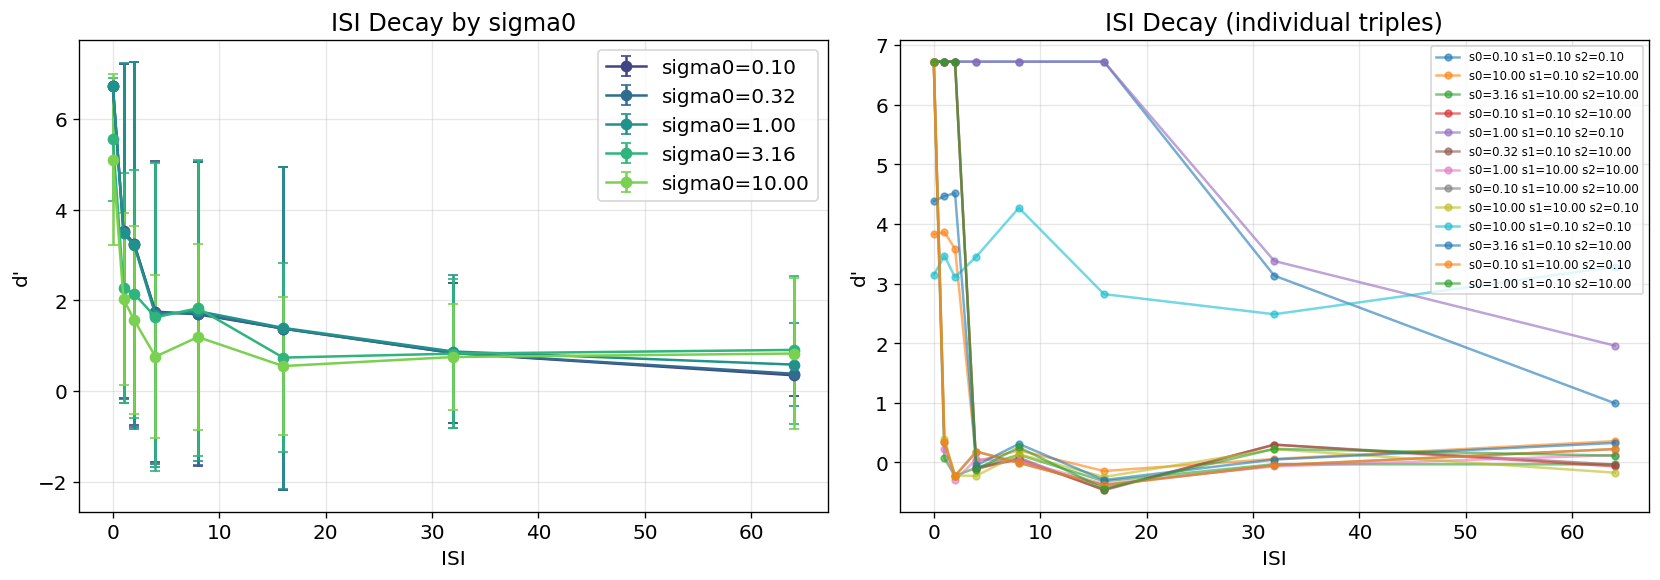

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
# Plot error bars (STD) for each ISI value per sigma0 on the left plot



# --- Left: ISI decay averaged over sigma1, sigma2 per sigma0 ---
ax = axes[0]
colors_s0 = plt.cm.viridis(np.linspace(0.2, 0.8, len(sigma0_grid)))

for s0, color in zip(sigma0_grid, colors_s0):
    sub = df[df['sigma0'] == s0]
    means = [sub[f'dprime_isi{isi}'].mean() for isi in ISI_VALUES]
    stds = [sub[f'dprime_isi{isi}'].std() for isi in ISI_VALUES]
    # Draw the line with error bars (std)
    ax.errorbar(ISI_VALUES, means, yerr=stds, marker='o', color=color, label=f'sigma0={s0:.2f}', capsize=3, linestyle='-')

ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('ISI Decay by sigma0')
ax.legend()
ax.grid(True, alpha=0.3)

# --- Right: individual triple curves (sample a few) ---
ax = axes[1]
sample = df.sample(n=min(13, len(df)), random_state=42)
print(len(df))

for _, row in sample.iterrows():
    dps = [row[f'dprime_isi{isi}'] for isi in ISI_VALUES]
    label = f's0={row["sigma0"]:.2f} s1={row["sigma1"]:.2f} s2={row["sigma2"]:.2f}'
    ax.plot(ISI_VALUES, dps, marker='o', alpha=0.6, markersize=4, label=label)
    

ax.set_xlabel('ISI')
ax.set_ylabel("d'")
ax.set_title('ISI Decay (individual triples)')
ax.legend(fontsize=7, loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 7. Verify: run_mc_dprime matches manual computation

In [37]:
# Run the same triple via run_mc_dprime
test_s0, test_s1, test_s2 = 0.3, 0.1, 0.05
test_seed = 99
test_nmc = 2

dp_func, _ = run_mc_dprime(
    test_s0, test_s1, test_s2,
    X0=X0, name_to_idx=name_to_idx,
    experiment_list=experiment_list,
    t_step=t_step,
    isi_values=tuple(ISI_VALUES),
    n_mc=test_nmc,
    seed=test_seed,
    metric=metric,
)

# Manual computation with same params
schedule = make_noise_schedule('three-regime', {
    'sigma0': test_s0, 'sigma1': test_s1, 'sigma2': test_s2, 't_step': t_step,
})
runner_isis = [isi + 1 for isi in ISI_VALUES]
manual_hits = defaultdict(list)
manual_fas = []

for rep in range(test_nmc):
    run = run_model_core(
        sigma0=test_s0,
        X0=X0, name_to_idx=name_to_idx,
        experiment_list=experiment_list,
        noise_schedule=schedule,
        metric=metric,
        seed=test_seed * 10_000 + rep,
    )
    for risi in runner_isis:
        manual_hits[risi].extend(run['isi_hit_dists'].get(risi, []))
    manual_fas.extend(run['fas'])

fas_arr = np.array(manual_fas, dtype=float)
st = 'distance' if metric != 'loglikelihood' else 'likelihood'

dp_manual = {}
for exp_isi, risi in zip(ISI_VALUES, runner_isis):
    hr = manual_hits.get(risi, [])
    if len(hr) < 3:
        dp_manual[exp_isi] = np.nan
        continue
    hs = np.array([s for s, t in hr], dtype=float)
    roc = roc_from_arrays(hs, fas_arr, score_type=st)
    if roc is not None:
        _, _, auc_val = roc
        dp_manual[exp_isi] = auroc_to_dprime(auc_val)
    else:
        dp_manual[exp_isi] = np.nan

print('Comparison: run_mc_dprime vs manual')
print(f'{"ISI":>5} {"run_mc_dprime":>15} {"manual":>15} {"match":>8}')
print('-' * 45)
for isi in ISI_VALUES:
    v1 = dp_func.get(isi, np.nan)
    v2 = dp_manual.get(isi, np.nan)
    match = np.isclose(v1, v2, atol=1e-6) or (np.isnan(v1) and np.isnan(v2))
    print(f"{isi:5d} {v1:15.6f} {v2:15.6f} {'OK' if match else 'MISMATCH':>8}")

Comparison: run_mc_dprime vs manual
  ISI   run_mc_dprime          manual    match
---------------------------------------------
    0        6.722357        6.722357       OK
    1        6.722357        6.722357       OK
    2        6.722357        6.722357       OK
    4        6.722357        6.722357       OK
    8        6.722357        6.722357       OK
   16        6.722357        6.722357       OK
   32        6.722357        6.722357       OK
   64        5.546207        5.546207       OK


## Summary

If all cells ran without error:
- Real stimulus encoding via ResNet50 layer4 works
- `run_model_core` + `ThreeRegimeNoise` produces hits/FAs with expected ISI structure
- d' is positive and generally decreases with ISI
- `run_mc_dprime()` matches manual computation exactly
- The grid search is ready for SLURM deployment